In [8]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 7
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_result"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [9]:
query_size=100
ion_mode=[-1,1]


In [10]:
# parse txt
df=[]
data_rows=[]
for charge in ion_mode:
    search_result_file=path_benchmark_data/f'compare_search_result_query_{query_size}_charge_{charge}.txt'
    
    current_row=[]
    with open(search_result_file, 'r') as f:
        for line in f.readlines():
            items=line.split(":", maxsplit=1)
            key, value=items
            key=key.strip()
            value=value.strip()
            if key=="query_scan":
                if current_row and 'query_scan' in current_row:
                        data_rows.append(current_row)
                
                current_row={'charge':charge, 'query_scan':int(value)}
            else:
                if value.lower() in ['true', 'false']:
                    if value.lower() == 'true':
                        current_row[key] = 1
                    else:
                        current_row[key] = 0
                else:
                    continue

        if current_row and 'query_scan' in current_row:
            data_rows.append(current_row)

df = pd.DataFrame(data_rows)
df

,charge,query_scan,open_search_dynamic_all_build_top_hits,open_search_dynamic_build_update_1_top_hits,open_search_dynamic_build_update_2_top_hits,neutral_loss_search_dynamic_all_build_top_hits,neutral_loss_search_dynamic_build_update_1_top_hits,neutral_loss_search_dynamic_build_update_2_top_hits,hybrid_search_dynamic_all_build_top_hits,hybrid_search_dynamic_build_update_1_top_hits,hybrid_search_dynamic_build_update_2_top_hits
0,-1,0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN
2,-1,0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
3,-1,1,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,-1,1,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
595,1,98,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN
596,1,98,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0
597,1,99,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
598,1,99,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN


In [ ]:
def plot_compare_search_result_top_hits(
        df,
        search_type,
        xlim,
        save_path
):

    # my_color_palette=sns.color_palette("tab20c", 20)
    # color_palette={
    #     1: my_color_palette[0],
    #     -1:my_color_palette[5]
    # }
    df_data=df[[f"{search_type}_search_dynamic_all_build_top_hits", 
              f"{search_type}_search_dynamic_build_update_1_top_hits",
              f"{search_type}_search_dynamic_build_update_2_top_hits", 
              'charge']]
    df_melted=df_data.melt(id_vars=["charge"], var_name="construction_type", value_name="top_hits_match")
    df_melted

    charge_stats=df_data.groupby('charge').mean() * 100
    charge_stats

    positive = charge_stats.loc[1].values
    negative = charge_stats.loc[-1].values

    metrics = [f'{search_type}_search_dynamic_all_build_top_hits', 
           f'{search_type}_search_dynamic_build_update_1_top_hits', 
           f'{search_type}_search_dynamic_build_update_2_top_hits']
    metric_labels = ['Construct 1M from scratch', 
                     'Construct 0.1M from scratch\nand insert 0.9M in 1 batch', 
                     'Construct 0.1M from scratch\nand insert 0.9M in 10 batches']
    fig, ax = plt.subplots(figsize=(7, 5))
    y = np.arange(len(metrics))
    height=0.35
    bars1 = ax.barh(y - height/2, positive, height, label='(+)ESI', 
                color='#FCD470', alpha=0.85, edgecolor='white', linewidth=1)
    bars2 = ax.barh(y + height/2, negative, height, label='(-)ESI', 
                color='#66BC98', alpha=0.85, edgecolor='white', linewidth=1)
    for bars in [bars1, bars2]:
        for bar in bars:
            width = bar.get_width()
            if width > 0:
                ax.text(width-14, bar.get_y() + bar.get_height()/2, 
                        f'{width:.1f}%', va='center', ha='left', fontsize=11, )
                
    ax.set_yticks(y)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_yticklabels(metric_labels, fontsize=12)
    ax.set_xlabel('Top hits match (%)', fontsize=12, labelpad=20)
    ax.set_title(f'Top hits match ({search_type.replace('_', ' ')} search)', fontsize=14, )
    left=xlim[0]
    right=xlim[1]
    ax.set_xlim(left=left, right=right)
    ax.legend(loc='upper center', framealpha=0.9, bbox_to_anchor=(0.5, 1.2), ncol=2,frameon=False, fontsize=14)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

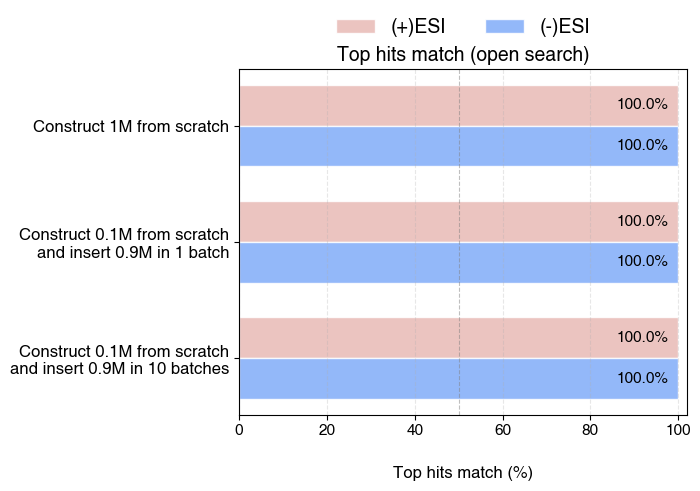

In [12]:
xlim=(0,102)
search_type='open'
save_path=path_figures / f"compare_search_result_top_hits_{search_type}_search.svg"
plot_compare_search_result_top_hits(
    df=df,
    search_type=search_type,
    xlim=xlim,
    save_path=save_path
)


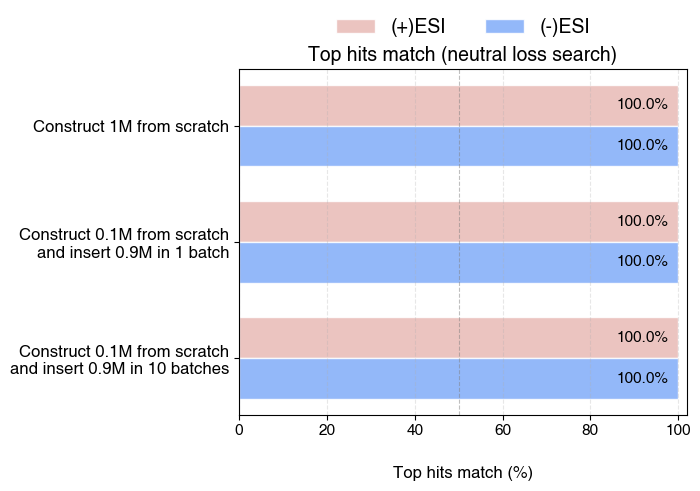

In [13]:
xlim=(0,102)
search_type='neutral_loss'
save_path=path_figures / f"compare_search_result_top_hits_{search_type}_search.svg"
plot_compare_search_result_top_hits(
    df=df,
    search_type=search_type,
    xlim=xlim,
    save_path=save_path
)


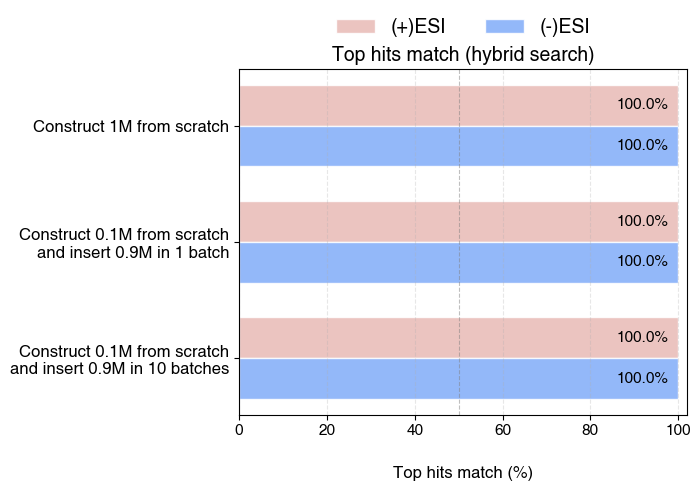

In [14]:
xlim=(0,102)
search_type='hybrid'
save_path=path_figures / f"compare_search_result_top_hits_{search_type}_search.svg"
plot_compare_search_result_top_hits(
    df=df,
    search_type=search_type,
    xlim=xlim,
    save_path=save_path
)
